In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

# Проверка GPU
print("GPU доступен:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.15.0
GPU доступен: []


In [2]:
# Загрузка CSV файла
df = pd.read_csv('D:/CV/Lab_4/A_Z Handwritten Data.csv')

# Посмотрим первые строки
print(df.head())
print(f"\nРазмер датасета: {df.shape}")

y = df.iloc[:, 0].values  # первая колонка - метки (0-25)
X = df.iloc[:, 1:].values  # остальные 784 колонки - пиксели

print(f"Загружено {len(df)} образцов")
print(f"Метки y: {y.shape}")
print(f"Признаки X: {X.shape}")

   0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  ...  0.639  0.640  0.641  \
0  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  0    0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.642  0.643  0.644  0.645  0.646  0.647  0.648  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]

Размер датасета: (372450, 785)
Загружено 372450 образцов
Метки y: (372450,)
Признаки X: (372450, 784)


In [3]:
total = 0
for i in range(26):
    indices = np.where(y == i)[0]  # ← нужно y == i, а не просто i
    print(f"Найдено образцов буквы {i} --- {chr(i + 65)}: {len(indices)}")
    total = total + len(indices)

print(f"Найдено всего {total}")



Найдено образцов буквы 0 --- A: 13869
Найдено образцов буквы 1 --- B: 8668
Найдено образцов буквы 2 --- C: 23409
Найдено образцов буквы 3 --- D: 10134
Найдено образцов буквы 4 --- E: 11440
Найдено образцов буквы 5 --- F: 1163
Найдено образцов буквы 6 --- G: 5762
Найдено образцов буквы 7 --- H: 7218
Найдено образцов буквы 8 --- I: 1120
Найдено образцов буквы 9 --- J: 8493
Найдено образцов буквы 10 --- K: 5603
Найдено образцов буквы 11 --- L: 11586
Найдено образцов буквы 12 --- M: 12336
Найдено образцов буквы 13 --- N: 19010
Найдено образцов буквы 14 --- O: 57825
Найдено образцов буквы 15 --- P: 19341
Найдено образцов буквы 16 --- Q: 5812
Найдено образцов буквы 17 --- R: 11566
Найдено образцов буквы 18 --- S: 48419
Найдено образцов буквы 19 --- T: 22495
Найдено образцов буквы 20 --- U: 29008
Найдено образцов буквы 21 --- V: 4182
Найдено образцов буквы 22 --- W: 10784
Найдено образцов буквы 23 --- X: 6272
Найдено образцов буквы 24 --- Y: 10859
Найдено образцов буквы 25 --- Z: 6076
Найдено

Найдено образцов буквы 'V': 4182


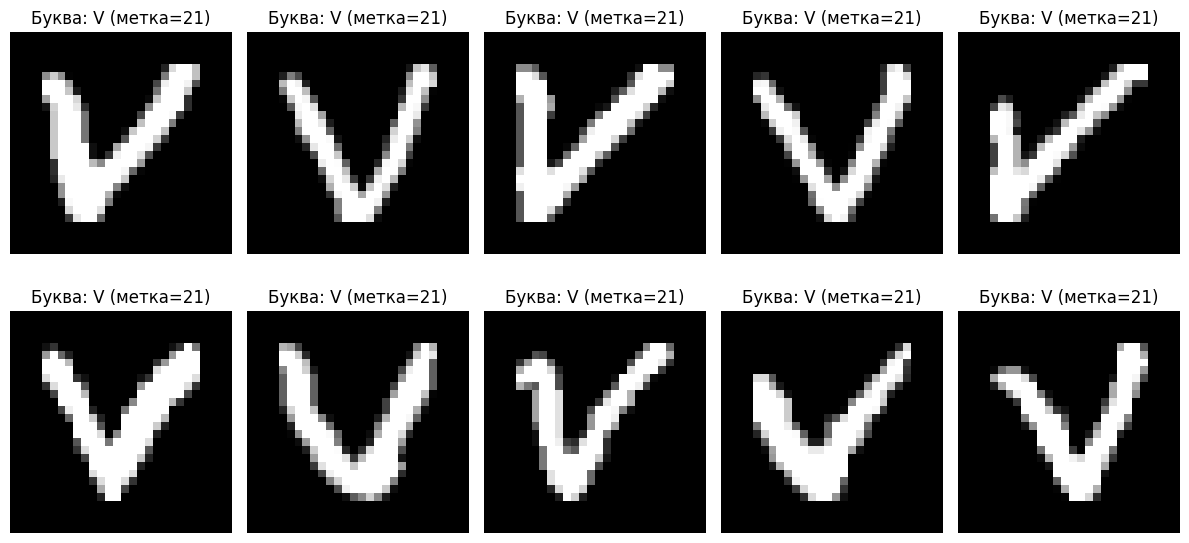

In [4]:
# Поиск букв
label_b = 21
indices_b = np.where(y == label_b)[0]

print(f"Найдено образцов буквы '{chr(label_b + 65)}': {len(indices_b)}")

# Покажем первые 10 образцов буквы "Б"
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < len(indices_b):
        idx = indices_b[i]
        img = X[idx].reshape(28, 28)
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Буква: {chr(label_b + 65)} (метка={y[idx]})')
        ax.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# Нормализация и подготовка
X = X.astype('float32') / 255.0
y_cat = to_categorical(y, num_classes=26)

# Изменение формы для CNN
X_cnn = X.reshape(-1, 28, 28, 1)

# Разделение на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_cat, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]}")
print(f"Тестовая выборка: {X_test.shape[0]}")

Обучающая выборка: 297960
Тестовая выборка: 74490


In [6]:
# Создание модели
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(26, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 128)             

In [7]:
# Обучение
history = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10


2096/2096 [==============================] - 62s 29ms/step - loss: 0.3215 - accuracy: 0.9076 - val_loss: 0.0850 - val_accuracy: 0.9763
Epoch 2/10
2096/2096 [==============================] - 58s 28ms/step - loss: 0.1344 - accuracy: 0.9622 - val_loss: 0.0684 - val_accuracy: 0.9809
Epoch 3/10
2096/2096 [==============================] - 58s 28ms/step - loss: 0.1037 - accuracy: 0.9712 - val_loss: 0.0564 - val_accuracy: 0.9843
Epoch 4/10
2096/2096 [==============================] - 58s 28ms/step - loss: 0.0859 - accuracy: 0.9758 - val_loss: 0.0513 - val_accuracy: 0.9857
Epoch 5/10
2096/2096 [==============================] - 69s 33ms/step - loss: 0.0741 - accuracy: 0.9790 - val_loss: 0.0502 - val_accuracy: 0.9870
Epoch 6/10
2096/2096 [==============================] - 61s 29ms/step - loss: 0.0651 - accuracy: 0.9814 - val_loss: 0.0437 - val_accuracy: 0.9888
Epoch 7/10
2096/2096 [==============================] - 59s 28ms/step - loss: 0.0589 - accuracy: 0.9829 - val_loss: 0.0411

In [8]:
# Оценка
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🎯 Точность на тестовой выборке: {test_acc*100:.2f}%")


🎯 Точность на тестовой выборке: 99.19%


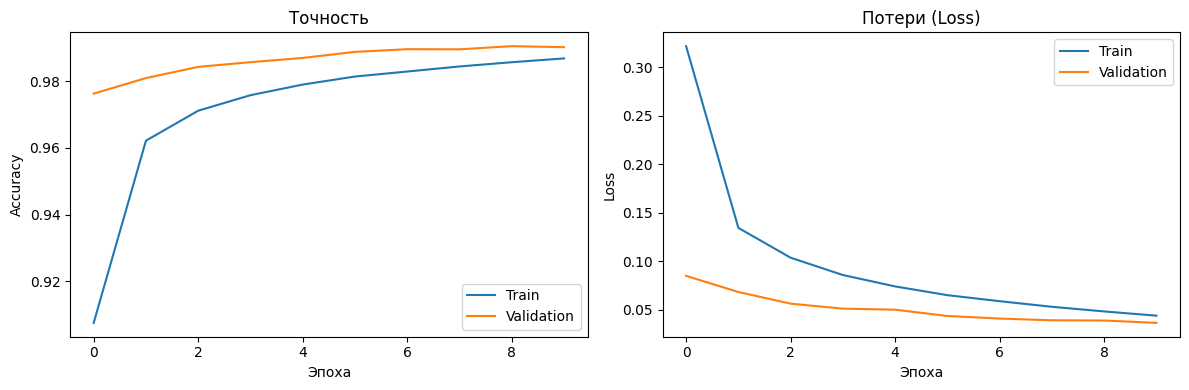

In [9]:
# График обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Точность')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Потери (Loss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# Пример предсказаний
predictions = model.predict(X_test[:10])
predicted = np.argmax(predictions, axis=1)
true = np.argmax(y_test[:10], axis=1)

for i in range(10):
    print(f"Образец {i+1}: Истинная буква = {chr(true[i]+65)}, Предсказанная = {chr(predicted[i]+65)}")

1/1 [==============================] - 0s 246ms/step
Образец 1: Истинная буква = M, Предсказанная = M
Образец 2: Истинная буква = S, Предсказанная = S
Образец 3: Истинная буква = C, Предсказанная = C
Образец 4: Истинная буква = O, Предсказанная = O
Образец 5: Истинная буква = A, Предсказанная = A
Образец 6: Истинная буква = L, Предсказанная = L
Образец 7: Истинная буква = O, Предсказанная = O
Образец 8: Истинная буква = C, Предсказанная = C
Образец 9: Истинная буква = T, Предсказанная = T
Образец 10: Истинная буква = W, Предсказанная = W


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Предсказания на тестовой выборке
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# Матрица ошибок (Confusion Matrix)
cm = confusion_matrix(y_true, y_pred)

# Названия букв
letters = [chr(i + 65) for i in range(26)]

# Построение корреляционной карты (матрицы ошибок)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, 
            annot=True,           # показывать числа
            fmt='d',              # целые числа
            cmap='Blues',         # цветовая схема
            xticklabels=letters,  # подписи по X (предсказанные буквы)
            yticklabels=letters,  # подписи по Y (истинные буквы)
            square=True,          # квадратные ячейки
            annot_kws={'size': 8}) # размер шрифта чисел

plt.title('Матрица корреляции (Confusion Matrix) - распознавание букв английского алфавита', fontsize=14)
plt.xlabel('Предсказанная буква', fontsize=12)
plt.ylabel('Истинная буква', fontsize=12)
plt.tight_layout()
plt.show()

# Дополнительно: нормализованная версия (в процентах)
plt.figure(figsize=(16, 14))
cm_norm = cm.astype('float32') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_norm, 
            annot=True, 
            fmt='.1f', 
            cmap='YlOrRd', 
            xticklabels=letters, 
            yticklabels=letters, 
            square=True, 
            annot_kws={'size': 8},
            vmin=0, 
            vmax=100)
plt.title('Нормализованная матрица ошибок (%) - распознавание букв', fontsize=14)
plt.xlabel('Предсказанная буква', fontsize=12)
plt.ylabel('Истинная буква', fontsize=12)
plt.tight_layout()
plt.show()

print(f"✅ Общая точность модели: {np.trace(cm) / np.sum(cm) * 100:.2f}%")

NameError: name 'model' is not defined